In [7]:
from pathlib import Path
import sys

# Add project root (.../CPSC_440_Project) to import path
sys.path.append(str(Path.cwd().parent))

from Utils.preprocess import preprocess_data
from Visuals.visuals import draw_ellipse
from Models.Gaussian import gaussian_model
from Models.GaussianMixture import gaussian_mixture_model
from Models.EneryDistance import gmm_energy_distance

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [3]:
dataset = preprocess_data()
dataset.head()

Combined dataset shape: (1633, 4)


,Name,Club,X,Y
0,Ryan,I7,-23.2,180.3
1,Ryan,I7,38.4,141.7
2,Ryan,I7,6.3,153.6
3,Ryan,I7,-7.6,49.7
4,Ryan,I7,11.2,162.1


In [4]:
counts_by_name_club = (
    dataset.groupby(["Name", "Club"]).size().reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

counts_by_name_club

,Name,Club,count
0,5,W1,340
1,2,W1,190
2,3,I7,166
3,3,W1,154
4,6,W1,142
5,4,W1,125
6,8,W1,90
7,1,W1,87
8,2,I7,82
9,1,I9,75


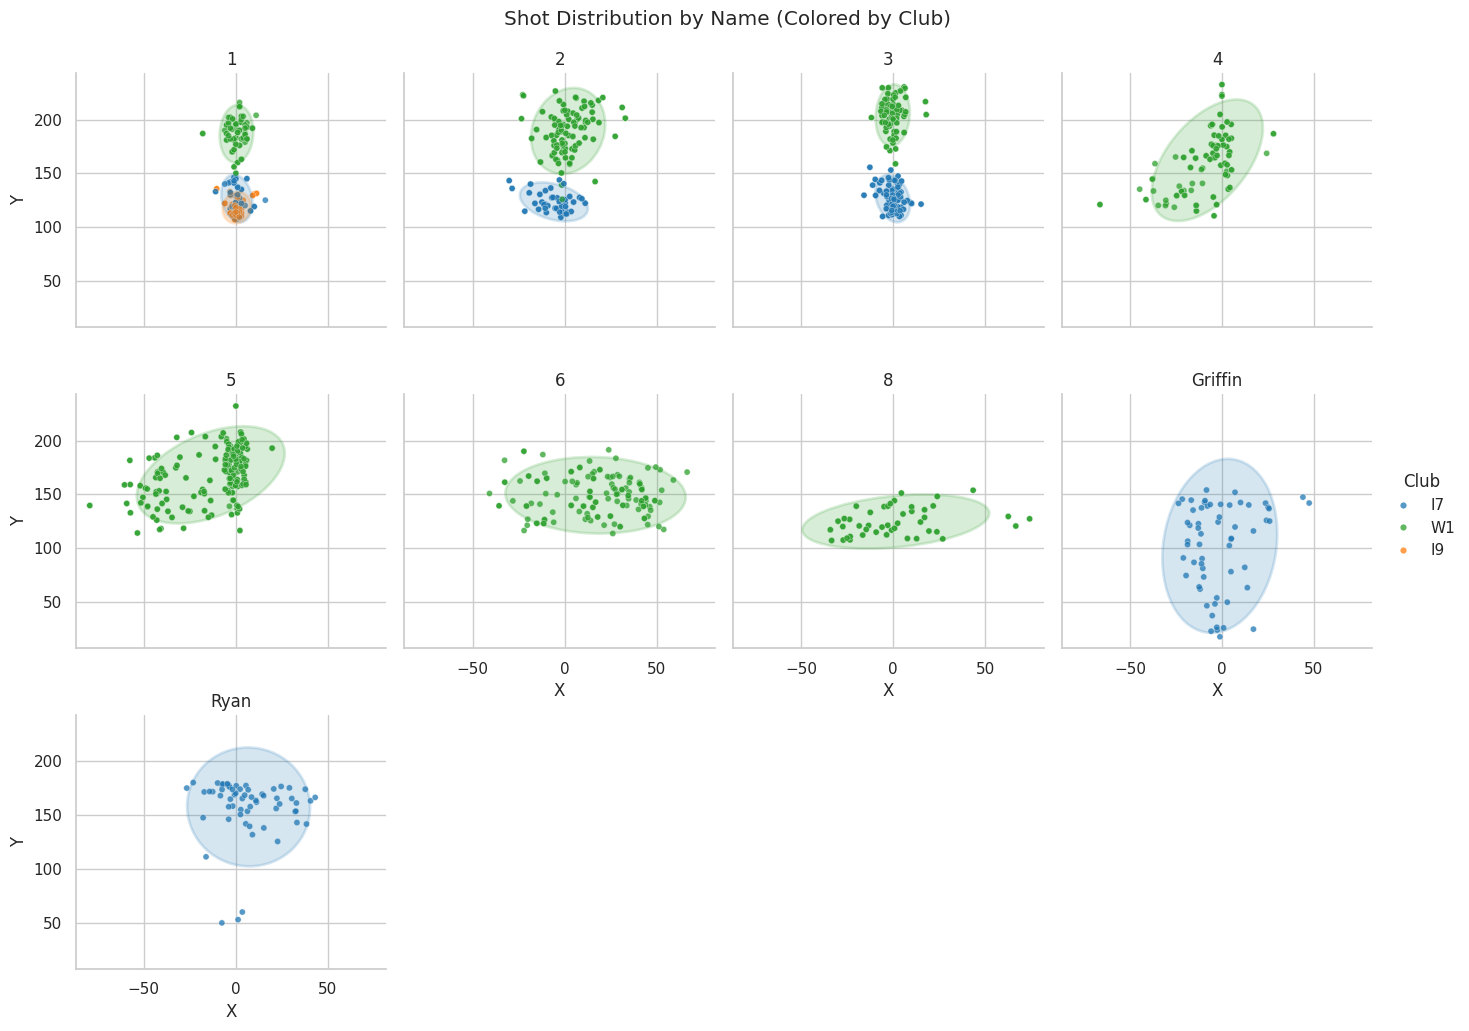

In [5]:


sns.set_theme(style="whitegrid")

plot_data = dataset.copy()
plot_data["Name"] = plot_data["Name"].astype(str)
plot_data["Club"] = plot_data["Club"].astype(str)
plot_data["X"] = plot_data["X"].astype(float)
plot_data["Y"] = plot_data["Y"].astype(float)

name_order = sorted(plot_data["Name"].dropna().unique())
club_order = sorted(plot_data["Club"].dropna().unique())
col_wrap = min(4, max(1, len(name_order)))
club_palette = dict(zip(club_order, sns.color_palette("tab10", n_colors=len(club_order))))


def covariance_ellipse(mean, covariance, n_std=2.0, **kwargs):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(eigenvalues, 0))
    return Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=True,
        **kwargs,
    )


g = sns.relplot(
    data=plot_data,
    x="X",
    y="Y",
    hue="Club",
    palette=club_palette,
    col="Name",
    col_order=name_order,
    col_wrap=col_wrap,
    kind="scatter",
    alpha=0.75,
    s=20,
    height=3.5,
    aspect=1,
    facet_kws={"sharex": True, "sharey": True},
)

for name, ax in g.axes_dict.items():
    subset_by_name = plot_data[plot_data["Name"] == name]
    for club, club_df in subset_by_name.groupby("Club"):
        if len(club_df) < 2:
            continue
        mean, covariance = gaussian_model(club_df["X"], club_df["Y"])
        ellipse = covariance_ellipse(
            mean,
            covariance,
            n_std=2.0,
            edgecolor=club_palette[club],
            facecolor=club_palette[club],
            linewidth=2,
            alpha=0.18,
        )
        ax.add_patch(ellipse)

g.set_axis_labels("X", "Y")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Shot Distribution by Name (Colored by Club)")
plt.show()

In [8]:
### Testing Energy Distance and BIC

ryan_data = dataset[dataset["Name"] == "Ryan"].dropna(subset=["X", "Y"])
features = ryan_data[["X", "Y"]]

for i in range(8):
    gmm = gaussian_mixture_model(features, n_components=i + 1)
    bic_value = gmm.bic(features)
    gmm_ed = gmm_energy_distance(gmm, features, n_samples=1000, random_state=42)
    print(f"BIC for components {i + 1}: {bic_value:.3f}")
    print(f"Energy Distance for {i + 1} components: {gmm_ed:.6f}")

BIC for components 1: 1115.285
Energy Distance for 1 components: 1.676817
BIC for components 2: 1069.707
Energy Distance for 2 components: 0.354699
BIC for components 3: 1060.686
Energy Distance for 3 components: 0.162330
BIC for components 4: 1079.009
Energy Distance for 4 components: 0.126840
BIC for components 5: 1097.949
Energy Distance for 5 components: 0.110349
BIC for components 6: 1079.742
Energy Distance for 6 components: 0.087040
BIC for components 7: 1092.297
Energy Distance for 7 components: 0.076959
BIC for components 8: 1106.730
Energy Distance for 8 components: 0.068773
